In [1]:
# PREPROCESSING CODE FOR IMAGING DATA with Behaviour
# Creates CSV, aligned the time events, runs suite2p and calculate dff for all cells
# Creates an analysis folder & saves necessary files for each recording session
# # This code creates necessary behaviour & imaging files
# It should work for any given task recorded in Dual2p or Packer 1 scope
# Requires MATLAB integration, and uses getBehavData matlab function
# 
# 30/08/2025 HA
%reload_ext autoreload
%autoreload 2

#make data file
print( "Takes <30s. However, it might take >1 mins or so if network is busy...")
import glob
import sys,os, glob, shutil
import pandas as pd
from datetime import datetime
import numpy as np
import main_funcs as mfun
import plot_funcs as pfun
import utils_funcs as utils # utils is from Vape - catcher file: 
import matplotlib.pyplot as plt
from scipy.stats import zscore
import pickle
import time
from LakLabAnalysis.Utility.extract_paq_events import extract_paq_data_frame
import LakLabAnalysis.Utility.utils_funcs as utils_laklab
from tifffile import TiffFile, imread, imwrite
import imageio.v2 as imageio
print('All libraries are loaded correctly.')
# set matlab API - I dont think we need MATLAB, if we need, uncomment
# import matlab.engine
# eng = matlab.engine.start_matlab()
# print('Matlab engine is set correctly.')


Takes <30s. However, it might take >1 mins or so if network is busy...
All libraries are loaded correctly.


In [ ]:

# TRY THIS - IF DO NOT WORK< CREATE YOUR INFO (MOST LIKELY WONT WORK AS PATHS ARE DIFFERENT) - THIS INFO FILE IS CREATED FOR THE RELEVANT ANIMAL, SO IT SHOULD WORK
# repo_analysis_path =  r'\\Qnap-Al001\LakGuest\Yuliia\sideBiasLateralization\analysis\info.pkl'
# info = pickle.load(open(os.path.join(repo_analysis_path, 'sideBiasLateralisation_info.pkl'), 'rb'))
# print('Info file is loaded correctly - Total recording sessions:', len(info.recordingList))

# CREATE INFO FOR THE RELEVANT ANIMAL - THIS TAKES 3mins for 4 animals, so be patient!
animalList= ['MAT057', 'MAT058','MAT068', 'MAT069']#,'MAT057','MAT058', 'MAT067', 'MAT068','MAT069']#] #
#'MAT038','MAT039', 'MAT045', 'MAT046','MAT066'
#,'HA011','HAT009','HAT010,'MBL015','MBL014',]

# Done:MBL014 & HAT009- completely bad ignore! 
info = mfun.analysis(animalList=animalList)
info.recordingList = info.recordingList[
    (info.recordingList['performance'] > 50) &
    (info.recordingList['twoP']) &
    (info.recordingList['duration'] > 20)
    ].reset_index(drop=True)
info = mfun.update_info(info)
print('Total Session fits the selection: ' +  str(info.recordingList.shape[0]))

Env: decMaking
Computer: Huriye Windows
Most likely expRef does not match Z:\MAT057\2025-11-05\1\2025-11-05_1_MAT057_Block.mat: not enough values to unpack (expected 3, got 2)
Total Session fits the selection: 66


: 

In [5]:
# Check if pupil data extraction is complete - if a folder exist with sesionName in this folder yes, if not, no
pupilExtractedPath  = r'\\Qnap-Al001\LakGuest\Yuliia\sideBiasLateralization\analysis'
for ind, recordingDate in enumerate(info.recordingList.recordingDate):
    sessionName = info.recordingList.sessionName[ind]
    if os.path.exists(os.path.join(pupilExtractedPath, sessionName)):
        info.recordingList.loc[ind, 'pupilExtracted'] = 1
    else:
        info.recordingList.loc[ind, 'pupilExtracted'] = 0
print('Pupil data extraction is checked. Pupil data extracted:', info.recordingList.pupilExtracted.sum())



Pupil data extraction is checked. Pupil data extracted: 11.0


In [88]:
info.recordingList

,animalID,recordingDate,recordingID,sessionName,twoP,path,imagingTiffFileNames,sessionNameWithPath,blockName,experimentDefinition,...,analysispathname,filepathname,PAQextracted,PAQdataFound,CSVcreated,CSVpath,suite2Pcreated,dffcreated,imagingDataExtracted,pupilExtracted
0,MAT057,2025-11-10,1,2025-11-10_1_MAT057,True,Z:\MAT057\2025-11-10,Z:\MAT057\2025-11-10\TwoP\2025-11-10_t-001,Z:\MAT057\2025-11-10\1\2025-11-10_1_MAT057_Blo...,2025-11-10_1_MAT057,Grating2AFC_variableStimSize_variabledelay,...,Y:\sideBiasLateralisation\analysis\2025-11-10_...,Z:\MAT057\2025-11-10\1,0,0,0,Y:\sideBiasLateralisation\analysis\2025-11-10_...,1,0,0,0.0
1,MAT057,2025-11-11,1,2025-11-11_1_MAT057,True,Z:\MAT057\2025-11-11,Z:\MAT057\2025-11-11\TwoP\2025-11-11_t-001,Z:\MAT057\2025-11-11\1\2025-11-11_1_MAT057_Blo...,2025-11-11_1_MAT057,Grating2AFC_variableStimSize_variabledelay,...,Y:\sideBiasLateralisation\analysis\2025-11-11_...,Z:\MAT057\2025-11-11\1,0,0,0,Y:\sideBiasLateralisation\analysis\2025-11-11_...,1,0,0,0.0
2,MAT057,2025-11-12,1,2025-11-12_1_MAT057,True,Z:\MAT057\2025-11-12,Z:\MAT057\2025-11-12\TwoP\2025-11-12_t-001,Z:\MAT057\2025-11-12\1\2025-11-12_1_MAT057_Blo...,2025-11-12_1_MAT057,Grating2AFC_variableStimSize_variabledelay,...,Y:\sideBiasLateralisation\analysis\2025-11-12_...,Z:\MAT057\2025-11-12\1,0,0,0,Y:\sideBiasLateralisation\analysis\2025-11-12_...,1,0,0,0.0
3,MAT057,2025-11-13,1,2025-11-13_1_MAT057,True,Z:\MAT057\2025-11-13,Z:\MAT057\2025-11-13\TwoP\2025-11-13_t-001,Z:\MAT057\2025-11-13\1\2025-11-13_1_MAT057_Blo...,2025-11-13_1_MAT057,Grating2AFC_variableStimSize_variabledelay,...,Y:\sideBiasLateralisation\analysis\2025-11-13_...,Z:\MAT057\2025-11-13\1,0,0,0,Y:\sideBiasLateralisation\analysis\2025-11-13_...,1,0,0,0.0
4,MAT057,2025-11-14,1,2025-11-14_1_MAT057,True,Z:\MAT057\2025-11-14,Z:\MAT057\2025-11-14\TwoP\2025-11-14_t-001,Z:\MAT057\2025-11-14\1\2025-11-14_1_MAT057_Blo...,2025-11-14_1_MAT057,Grating2AFC_variableStimSize_variabledelay,...,Y:\sideBiasLateralisation\analysis\2025-11-14_...,Z:\MAT057\2025-11-14\1,0,0,0,Y:\sideBiasLateralisation\analysis\2025-11-14_...,1,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,MAT069,2025-12-02,1,2025-12-02_1_MAT069,True,Z:\MAT069\2025-12-02,Z:\MAT069\2025-12-02\TwoP\2025-12-02_t-001,Z:\MAT069\2025-12-02\1\2025-12-02_1_MAT069_Blo...,2025-12-02_1_MAT069,Grating2AFC_variableStimSize_variabledelay,...,Y:\sideBiasLateralisation\analysis\2025-12-02_...,Z:\MAT069\2025-12-02\1,0,0,0,Y:\sideBiasLateralisation\analysis\2025-12-02_...,1,0,0,0.0
62,MAT069,2025-12-04,1,2025-12-04_1_MAT069,True,Z:\MAT069\2025-12-04,Z:\MAT069\2025-12-04\TwoP\2025-12-04_t-001,Z:\MAT069\2025-12-04\1\2025-12-04_1_MAT069_Blo...,2025-12-04_1_MAT069,Grating2AFC_variableStimSize_variabledelay,...,Y:\sideBiasLateralisation\analysis\2025-12-04_...,Z:\MAT069\2025-12-04\1,0,0,0,Y:\sideBiasLateralisation\analysis\2025-12-04_...,1,0,0,1.0
63,MAT069,2025-12-06,1,2025-12-06_1_MAT069,True,Z:\MAT069\2025-12-06,Z:\MAT069\2025-12-06\TwoP\2025-12-06_t-001,Z:\MAT069\2025-12-06\1\2025-12-06_1_MAT069_Blo...,2025-12-06_1_MAT069,Grating2AFC_variableStimSize_variabledelay,...,Y:\sideBiasLateralisation\analysis\2025-12-06_...,Z:\MAT069\2025-12-06\1,0,0,0,Y:\sideBiasLateralisation\analysis\2025-12-06_...,1,0,0,1.0
64,MAT069,2025-12-07,1,2025-12-07_1_MAT069,True,Z:\MAT069\2025-12-07,Z:\MAT069\2025-12-07\TwoP\2025-12-07_t-001,Z:\MAT069\2025-12-07\1\2025-12-07_1_MAT069_Blo...,2025-12-07_1_MAT069,Grating2AFC_variableStimSize_variabledelay,...,Y:\sideBiasLateralisation\analysis\2025-12-07_...,Z:\MAT069\2025-12-07\1,0,0,0,Y:\sideBiasLateralisation\analysis\2025-12-07_...,1,0,0,1.0


In [127]:
def get_first_frame_per_stim(path,
                             recordingID,
                             eventSeries1='photodiode',
                             eventSeries2='eye_camera',
                             fs=2000,
                             gap_sec=2,
                             verbose=False):
    """
    Align stimulus pulses with camera frame pulses.

    Parameters
    ----------
    path : str
        Recording folder path
    recordingID : str
        Recording ID folder
    eventSeries1 : str
        Stimulus event file name prefix (default 'photodiode')
    eventSeries2 : str
        Camera event file name prefix (default 'eye_camera')
    fs : int
        Sampling rate (Hz)
    gap_sec : float
        Minimum gap between stimulus trains (sec)
    verbose : bool
        Print debugging information

    Returns
    -------
    first_stim_pulses : array
        Sample index of first photodiode pulse for each stimulus
    first_frame_number_per_stim : array
        Frame number (1-based) aligned to each stimulus
    first_frame_sample_per_stim : array
        Sample index of the corresponding eye frame pulse
    """
    # Load data
    eyeFrameFileName = os.path.join(path, recordingID, f'{eventSeries2}.raw.npy')
    stimFrameFileName = os.path.join(path, recordingID, f'{eventSeries1}.raw.npy')

    eyeFrame = np.load(eyeFrameFileName)
    stimFrame = np.load(stimFrameFileName).squeeze()

    # Rising edge detector
    def detect_rising_edges(signal, threshold=None):
        signal = np.asarray(signal).squeeze()

        if threshold is None:
            threshold = (np.min(signal) + np.max(signal)) / 2

        binary = signal > threshold
        rising = np.where((~binary[:-1]) & (binary[1:]))[0] + 1
        return rising, threshold

    stim_rise, stim_thr = detect_rising_edges(stimFrame)
    eye_rise, eye_thr = detect_rising_edges(eyeFrame)

    if verbose:
        print("All stim pulses detected:", len(stim_rise))
        print("All eye pulses detected:", len(eye_rise))
    # Detect first pulse per stimulus - there are multiple pulses per stimulus, we want to align to the first one. 
    # We assume that there is at least gap_sec seconds between stimulus trains, 
    # so if the gap between two pulses is larger than gap_sec, we consider it as a new stimulus train.
    new_stim_gap_samples = int(gap_sec * fs)

    first_stim_pulses = [stim_rise[0]]

    for i in range(1, len(stim_rise)):
        if stim_rise[i] - stim_rise[i - 1] > new_stim_gap_samples:
            first_stim_pulses.append(stim_rise[i])

    first_stim_pulses = np.array(first_stim_pulses)

    if verbose:
        print(f"First ten {eventSeries1} pulse per stimulus:",
              first_stim_pulses.shape, first_stim_pulses[:10])

    # Align to eye frames
    first_frame_number_per_stim = []
    first_frame_sample_per_stim = []

    for s in first_stim_pulses:

        k = np.searchsorted(eye_rise, s, side='left')

        if k < len(eye_rise):
            first_frame_number_per_stim.append(k + 1)  # 1-based
            first_frame_sample_per_stim.append(eye_rise[k])
        else:
            first_frame_number_per_stim.append(np.nan)
            first_frame_sample_per_stim.append(np.nan)

    first_frame_number_per_stim = np.array(first_frame_number_per_stim)
    first_frame_sample_per_stim = np.array(first_frame_sample_per_stim)

    if verbose:
        print(f"First ten {eventSeries2} frame number for each stimulus:",
              first_frame_number_per_stim.shape,
              first_frame_number_per_stim[:10])

    return first_frame_number_per_stim

In [ ]:
frame_numbers = utils.get_first_frame_per_stim(
    path=info.recordingList.path[0],
    recordingID=info.recordingList.recordingID[0],
    fs=2000
)

All stim pulses detected: 71994
All eye pulses detected: 70412
First ten photodiode pulse per stimulus: (266,) [  5584  36080  79622 105776 131408 162575 191613 218721 256259 296612]
First ten eye_camera frame number for each stimulus: (266,) [  47  352  787 1049 1305 1617 1907 2178 2553 2957]


In [123]:

# Load data
eyeFrameFileName = os.path.join(info.recordingList.path[0],
                                info.recordingList.recordingID[0],
                                'eye_camera.raw.npy')
eyeFrame = np.load(eyeFrameFileName)

stimFrameFileName = os.path.join(info.recordingList.path[0],
                                 info.recordingList.recordingID[0],
                                 'photodiode.raw.npy')
stimFrame = np.load(stimFrameFileName).squeeze()

# Choose eye pulse channel
if eyeFrame.ndim > 1:
    eyePulse = eyeFrame[:, 0]   # change if needed
else:
    eyePulse = eyeFrame.squeeze()

# -----------------------------------
# helper: rising edge detector
# -----------------------------------
def detect_rising_edges(signal, threshold=None):
    signal = np.asarray(signal).squeeze()

    if threshold is None:
        threshold = (np.min(signal) + np.max(signal)) / 2

    binary = signal > threshold
    rising = np.where((~binary[:-1]) & (binary[1:]))[0] + 1
    return rising, threshold

# detect all stim pulses and eye pulses
stim_rise, stim_thr = detect_rising_edges(stimFrame, threshold=None)
eye_rise, eye_thr = detect_rising_edges(eyePulse, threshold=None)

print("All stim pulses detected:", len(stim_rise))
print("All eye pulses detected:", len(eye_rise))

fs = 2000  # replace with your real sampling rate
new_stim_gap_sec = 2
new_stim_gap_samples = int(new_stim_gap_sec * fs)

# first pulse always starts a stimulus
first_stim_pulses = [stim_rise[0]]

# whenever the gap from previous pulse is large, start a new stimulus
for i in range(1, len(stim_rise)):
    if stim_rise[i] - stim_rise[i - 1] > new_stim_gap_samples:
        first_stim_pulses.append(stim_rise[i])

first_stim_pulses = np.array(first_stim_pulses)

print("First photodiode pulse for each stimulus:")
print(first_stim_pulses.shape,first_stim_pulses[0:10])

first_frame_number_per_stim = []
first_frame_sample_per_stim = []

for s in first_stim_pulses:
    k = np.searchsorted(eye_rise, s, side='left')
    if k < len(eye_rise):
        first_frame_number_per_stim.append(k + 1)   # 1-based frame number
        first_frame_sample_per_stim.append(eye_rise[k])
    else:
        first_frame_number_per_stim.append(np.nan)
        first_frame_sample_per_stim.append(np.nan)

first_frame_number_per_stim = np.array(first_frame_number_per_stim)
first_frame_sample_per_stim = np.array(first_frame_sample_per_stim)

print("First eye frame number for each stimulus:")
print(first_frame_number_per_stim.shape, first_frame_number_per_stim[0:10])

All stim pulses detected: 71994
All eye pulses detected: 70412
First photodiode pulse for each stimulus:
(266,) [  5584  36080  79622 105776 131408 162575 191613 218721 256259 296612]
First eye frame number for each stimulus:
(266,) [  47  352  787 1049 1305 1617 1907 2178 2553 2957]


Eye frame data loaded correctly. Shape: (7046000, 1)


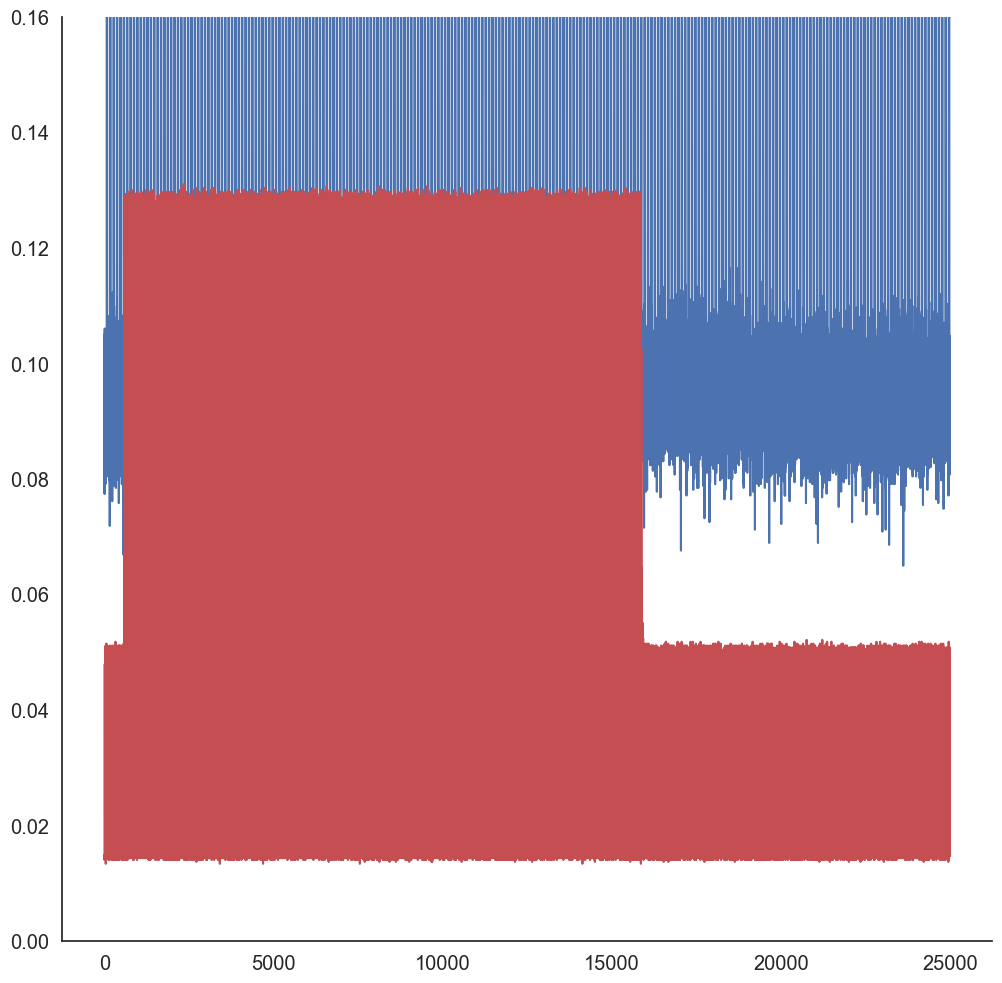

In [108]:
eyeFrameFileName = os.path.join(info.recordingList.path[0], info.recordingList.recordingID[0],'eye_camera.raw.npy')
eyeFrame = np.load(eyeFrameFileName)

stimFrameFileName = os.path.join(info.recordingList.path[0], info.recordingList.recordingID[0],'photodiode.raw.npy')
stimFrame = np.load(stimFrameFileName)

print('Eye frame data loaded correctly. Shape:', eyeFrame.shape)
# plot the first frame to check
plt.plot( eyeFrame[5000:30000,:])
plt.plot(stimFrame[5000:30000], 'r')
plt.ylim(0., 0.16)
plt.show()

In [169]:
np.diff(visTimes)

array([14.68101481, 30.78941521,  8.73041666, 17.13488735, 15.96856281,
       14.23358754, 10.18212509, 13.04693722, 14.83789183,  7.56414045,
       10.02930138,  7.75623058, 14.06154034, 13.92097376, 13.61707891,
        9.0524506 , 10.32740882, 15.08703616, 15.98137868,  9.96594977,
       15.89065101, 11.36705083, 11.42850264, 10.31449766, 10.33446882,
       12.10206257, 11.18408823,  8.68091594, 11.66894324, 15.98793632,
       15.14408504, 11.30307983,  7.55141216, 10.78101577, 12.38195559,
       14.80546884, 10.46325012, 10.9983478 , 12.78859877, 18.06088105,
       12.55585546, 11.87916876, 10.85744194,  7.56083093,  9.83176089,
        9.60092492, 11.75397364, 11.54576809, 15.23935074,  8.51641211,
        8.84463843,  9.65690303, 10.8609211 , 13.06555923, 12.58373372,
        7.53737861, 10.56338285, 14.87446601, 11.96103774, 10.76567231,
       20.2530736 , 15.07119591, 10.22850168, 11.63250989, 12.55352033,
       12.31413474, 13.26485052, 14.96903695, 13.61869968, 10.52

In [168]:
np.diff([  4765,  34127,  95706, 113166, 147436, 179374, 207841, 228205, 254298, 283974])/2000

array([14.681 , 30.7895,  8.73  , 17.135 , 15.969 , 14.2335, 10.182 ,
       13.0465, 14.838 ])

In [239]:
# Plotting params
pfun.set_figure()

## Parameters
fps = 20
fs = 1000
fRate = fs/fps
responsiveness_test_duration = 1000.0 #in ms 
responsiveness_test_duration_frames = int(np.ceil(responsiveness_test_duration/fRate))
pre_frames    = 2000.0# in ms
pre_frames    = int(np.ceil(pre_frames/fRate))
post_frames   = 6000.0 # in ms
post_frames   = int(np.ceil(post_frames/fRate))
analysisWindowDur = 750 # in ms
analysisWindowDur = int(np.ceil(analysisWindowDur/fRate))
simulationDur_ms = 2000.0 # in ms 
simulationDur  = int(np.ceil(simulationDur_ms/fRate))
duration ='5'

params ={}
params['fps'] = fps
params['fRate'] = fRate
params['responsiveness_test_duration'] = responsiveness_test_duration
params['responsiveness_test_duration_frames'] = responsiveness_test_duration_frames
params['pre_frames'] = pre_frames
params['post_frames'] = post_frames
params['analysisWindowDur'] = analysisWindowDur
params['simulationDur_ms'] = simulationDur_ms
params['simulationDur'] = simulationDur

pd.set_option('mode.chained_assignment', None)
# You should always read the saved info! Get the list to extract the files for further analysis
# # load info from pickle

In [246]:
# Extract necessary files for each session
use_responsive_only = False  # Change to False to use all neurons // Option to use only responsive neurons

for ind, recordingDate in enumerate(info.recordingList.recordingDate):
   # if all_neurons folder is not exist in the naalysis path
   allNeurons_path = os.path.join(info.recordingList.analysispathname[ind], 'all_neurons')
   try:
      if (info.recordingList.loc[ind, 'pupilExtracted'] == 1) :# 
         print(str(ind) + ': Creating: ' + info.recordingList.analysispathname[ind])
         #Create a huge dictionary with all cells and parameters for each cell
         pathname = info.recordingList.analysispathname[ind]
         # create the folder if it does not exist
         if not os.path.exists(pathname):
            os.makedirs(pathname)

      ########## GET BEHAVIOURAL OUTPUT
         filenameCSV = info.recordingList.analysispathname[ind] + info.recordingList.sessionName[ind] + '_CorrectedeventTimes.csv'
         print()
         filenameCSV = [f for f in glob.glob(filenameCSV)]    
         behData     = pd.read_csv(filenameCSV[0], header=0)
         visTimes    = behData['stimulusOnsetTime'] #+ behData['trialOffsets']
         rewardTimes = behData['rewardTime']# + behData['trialOffsets']
         choice      = behData['choice']
         choiceTimes = behData['choiceStartTime'] # + behData['trialOffsets']
         stimSide = behData['correctResponse']

         # get recording side 
         tiff_path    = info.recordingList.imagingTiffFileNames[ind]
         behData_aug = mfun.add_trial_side_info(behData, tiff_path)

         recordingSideStim = behData_aug['recordingSideStim']
         biasStim = behData_aug['biasStim']
         recordingSideChoice = behData_aug['recordingSideChoice']
         biasChoice = behData_aug['biasChoice']
      
         # Make a variable for rewarded trials
         rewarded    =  behData['rewardTime'].notna() # True for rewarded which also means correct response
         # Calculate reward Time for non-rewarded Trials
         choiceCompleteTimes = behData['choiceCompleteTime'] #+ behData['trialOffsets']
         diff_time = np.nanmean(rewardTimes -choiceTimes)
         nan_indices = np.isnan(rewardTimes) # unrewarded trials
         rewardTimes[nan_indices] = choiceCompleteTimes[nan_indices] + diff_time
         
         # Create variable stimulus that takes the non-zero value of contrastLeft or contrastRight
         stimulus = np.where(behData['contrastLeft'] != 0, -behData['contrastLeft'], behData['contrastRight'])

         # Get the stim start times 
         filenameTXT = os.path.join(info.recordingList.path[ind],'twoP') +'\*_imaging_frames.txt'
         filenameTXT= [f for f in glob.glob(filenameTXT)]    
         frame_clock = pd.read_csv(filenameTXT[0],  header= None)
            
         stimFrameTimes  = utils.alignTwoSeries( path=info.recordingList.path[ind],
                           recordingID=info.recordingList.recordingID[ind],
                           eventSeries1='photodiode', eventSeries2='eye_camera',
                           fs=2000, verbose=False)
         print('Stimulus frame times are aligned correctly. Number of stimulus frames:', len(stimFrameTimes))
         print('First 10 stimulus frame times (in seconds):', stimFrameTimes[:10]/fps)
         rewardFrameTimes = stimFrameTimes + np.ceil((rewardTimes - visTimes) * fps)
         choiceFrameTimes = stimFrameTimes + np.ceil((choiceTimes - visTimes) * fps)

      ########## GET PUPIL IMAGING DATA ( in csv)
         pupilRawCSV = pd.read_csv(os.path.join(pupilExtractedPath, info.recordingList.sessionName[ind],
                                                info.recordingList.sessionName[ind] +'_pupil_analysis_results_26022026.csv'))
         pupilTrace   = pupilRawCSV['radius_px'].values
         # lets zscore
         pupilTrace = zscore(pupilTrace)

         # fig, ax = plt.subplots(figsize=(10, 4))
         # ax.plot(pupilTrace, color='blue')
         # ax.set_xlim(0, 300*fps)
         # plt.show()
         # print(' Done after pupilTrace')
       
      ########## CREATE INTERESTED TRIAL TYPES
         tTypesName, tTypes = mfun.build_trial_types(
                                                      behData,
                                                      rewarded,
                                                      choice,
                                                      stimSide,
                                                      stimulus,
                                                      recordingSideStim,
                                                      biasStim,
                                                      recordingSideChoice,
                                                      biasChoice
                                                      )

         ########## CREATE TRIAL TYPE SPECIFIC TRACES
         # --- FULL pupil TRACE ---
         pupilTrace_reward, pupilTrace_mean_reward = {}, {}
         pupilTrace_stimuli, pupilTrace_mean_stimuli = {}, {}
         pupilTrace_choice, pupilTrace_mean_choice = {}, {}
         pupil_mean_stimuli, pupil_mean_reward, pupil_mean_choice = {}, {}, {}
         pupilTrace_mean_stimuli_baseline, pupilTrace_mean_reward_baseline, pupilTrace_mean_choice_baseline = {}, {}, {}
         for indx, t in enumerate(tTypesName):
            # For reward
            selected_indices = [rewardFrameTimes[i] for i in np.where((tTypes[indx]==True)& (~np.isnan(rewardFrameTimes)))[0]]  
            selected_indices = [value for value in selected_indices if value == value]
            pupilTrace_reward[t] = utils.singleTrace_splitter(pupilTrace,selected_indices, pre_frames, post_frames)  # Cell x time x trial
            pupilTrace_mean_reward[t] = np.mean(pupilTrace_reward[t],2) if len(selected_indices)>2 else None # Cell x time
            pupil_mean_reward[t] = np.nanmean(pupilTrace_mean_reward[t][:, (pre_frames): (pre_frames + analysisWindowDur)],1) if len(selected_indices)>2 else None
            baseline  = np.nanmean(pupilTrace_mean_reward[t][:, (pre_frames - int(fps)): pre_frames],axis=1, keepdims=True) if len(selected_indices)>2 else None
            pupilTrace_mean_reward_baseline[t] = (pupilTrace_mean_reward[t] - baseline)  if len(selected_indices)>2 else None
            print(f'Completed reward for {t} - number of trials: {len(selected_indices)}')
             # For stimuli
            selected_indices = [stimFrameTimes[i] for i in np.where(tTypes[indx]==True)[0]]
            selected_indices = [value for value in selected_indices if value == value]
            pupilTrace_stimuli[t] = utils.singleTrace_splitter(pupilTrace, selected_indices, pre_frames, post_frames) # Cell x time x trial 
            pupilTrace_mean_stimuli[t] = np.mean(pupilTrace_stimuli[t],2) if len(selected_indices)>2 else None # Cell x time
            pupil_mean_stimuli[t] = np.nanmean(pupilTrace_mean_stimuli[t][:, (pre_frames): (pre_frames + analysisWindowDur)],1) if len(selected_indices)>2 else None
            baseline  = np.nanmean(pupilTrace_mean_stimuli[t][:, (pre_frames - int(fps)): pre_frames],axis=1, keepdims=True) if len(selected_indices)>2 else None
            pupilTrace_mean_stimuli_baseline[t] = (pupilTrace_mean_stimuli[t] - baseline) if len(selected_indices)>2 else None

            # For choice
            selected_indices = [choiceFrameTimes[i] for i in np.where((tTypes[indx]==True)& (~np.isnan(choiceFrameTimes)))[0]] 
            selected_indices = [value for value in selected_indices if value == value]
            pupilTrace_choice[t] = utils.singleTrace_splitter(pupilTrace, selected_indices, pre_frames, post_frames) # Cell x time x trial
            pupilTrace_mean_choice[t] = np.mean(pupilTrace_choice[t],2) if len(selected_indices)>2 else None # Cell x time
            pupil_mean_choice[t] = np.nanmean(pupilTrace_mean_choice[t][:, (pre_frames): (pre_frames + analysisWindowDur)],1) if len(selected_indices)>2 else None
            baseline  = np.nanmean(pupilTrace_mean_choice[t][:, (pre_frames - int(fps)): pre_frames],axis=1, keepdims=True) if len(selected_indices)>2 else None
            pupilTrace_mean_choice_baseline[t] = (pupilTrace_mean_choice[t] - baseline) if len(selected_indices)>2 else None


           # --- DO WE NEED Z-SCORED ? IF SO ADD ACCORDINGLY---

         print('DONE')
         ########## LETS SAVE VARIABLES

         # Determine subfolder based on use_responsive_only
         subfolder = 'responsive_neurons' if use_responsive_only else 'all_neurons'
         subfolder_path = os.path.join(pathname, subfolder)
         os.makedirs(subfolder_path, exist_ok=True)

         # Save params in the appropriate subfolder
         filenameINFO = os.path.join(subfolder_path, 'pupil-pupilTrace.pkl')
         print('Saving: '+ filenameINFO)
         with open(filenameINFO, 'wb') as f:
            pickle.dump([pupilTrace_reward,pupilTrace_stimuli, pupilTrace_choice] , f)

         filenameINFO = os.path.join(subfolder_path, 'pupil-pupilTrace_mean.pkl')
         print('Saving: '+ filenameINFO)
         with open(filenameINFO, 'wb') as f:
            pickle.dump([pupilTrace_mean_reward,
                        pupilTrace_mean_stimuli,
                        pupilTrace_mean_choice ] , f)

         filenameINFO = os.path.join(subfolder_path, 'pupil-pupil_mean.pkl')
         print('Saving: '+ filenameINFO)
         with open(filenameINFO, 'wb') as f:
            pickle.dump([pupil_mean_reward,
                        pupil_mean_stimuli,
                        pupil_mean_choice ] , f)
            
         filenameINFO = os.path.join(subfolder_path, 'pupil-pupilTrace_mean_baseline.pkl')
         print('Saving: '+ filenameINFO)
         with open(filenameINFO, 'wb') as f:
            pickle.dump([pupilTrace_mean_reward_baseline,
                        pupilTrace_mean_stimuli_baseline,
                        pupilTrace_mean_choice_baseline ] , f)
            
         print('Done - after saving')
         ########## LETS CREATE SOME HEATMAPS
         colormap = 'viridis'
         selectedSession = 'WithinSession'
         
         savefigname = 'Pupil-Heatmap-reward_' + str(duration[0]) + 'sec'
         analysis_params = ['Rewarded', 'Unrewarded']
         pfun.heatmap_sessions(pupilTrace_reward, analysis_params, colormap,
                              selectedSession, duration, savefigname, subfolder_path,
                              params = params)  
         plt.close()
                        
         savefigname = 'Pupil-Heatmap-choice_' + str(duration[0]) + 'sec'
         analysis_params = ['Left Choices','Right Choices']
         pfun.heatmap_sessions(pupilTrace_choice, analysis_params, colormap,
                              selectedSession, duration, savefigname, subfolder_path,
                              params = params) 
         plt.close()

         savefigname = 'Pupil-Heatmap-stimuli_' + str(duration[0]) + 'sec'
         analysis_params = ['0','-0.0625','-0.125', '-0.25', '-0.5']
         pfun.heatmap_sessions(pupilTrace_stimuli, analysis_params, colormap,
                              selectedSession, duration, savefigname, subfolder_path,
                              params = params) 
         plt.close()
         print('Done - after heatmap')

         ########## LETS CREATE SOME LINEPLOTS for Average Traces
         zscoreRun = False 
         baseline_subtract = [-1.0, 0.0]  # Baseline window: 1 second before stimulus onset

         # Get animal number and session info
         session_name = info.recordingList.sessionName[ind]
         title_prefix = f'{session_name}'

         colormap = ['red', 'black']
         savefigname = 'Pupil_LinePlot-mean-reward_' + str(duration[0]) + 'sec'
         analysis_params = ['Rewarded', 'Unrewarded']
         pfun.lineplot_sessions(pupilTrace_mean_reward, analysis_params, colormap,
                              duration, zscoreRun, savefigname, subfolder_path, baseline_subtract, 
                              title=f'{title_prefix} - Rewarded vs Unrewarded / reward aligned',
                              visualParams = params)
         plt.close()

         colormap = ['blue', 'red']
         savefigname = 'Pupil_LinePlot-mean-choice_' + str(duration[0]) + 'sec'
         analysis_params = ['Left Choices','Right Choices']
         pfun.lineplot_sessions(pupilTrace_mean_choice, analysis_params, colormap,
                              duration, zscoreRun, savefigname, subfolder_path, baseline_subtract,
                              title=f'{title_prefix} - Choice side / choice aligned',
                              visualParams = params)
         plt.close()

         ###### CONTRAST - Stimulus Aligned - Excited & inhibited cells separately
         colormap = 'viridis'
         analysis_params = ['0.5 Rewarded', '0.25 Rewarded','0.125 Rewarded','0.0625 Rewarded','0 Rewarded']
         pfun.set_figure()
         fig = plt.figure(constrained_layout=False, figsize=(8, 4)) # 8,11 for full A4 page

         gs_contrast  = fig.add_gridspec(ncols=1, nrows=1, bottom=0, top=0.8, left=0.05, right=0.95,
                                    wspace=0.5, hspace=0.6)
         ax_contrast = {xx: fig.add_subplot(gs_contrast[xx]) for xx in range(1)}

         pfun.lineplot_sessions(pupilTrace_mean_stimuli, analysis_params, colormap,
                                       duration, zscoreRun, savefigname, subfolder_path, baseline_subtract,
                                       title=f'{title_prefix}', axes=ax_contrast[0], 
                                       visualParams = params)

         # save the figure
         savefigname = 'Pupil-LinePlot_Contrast-stimuliAligned-rewarded'
         pfun.save_figure(savefigname, subfolder_path)
         plt.close()

         print('Completed')
         info.recordingList.loc[ind,'analysisVariableExtracted'] = 1
   except Exception as e:
      print(f">>>>>>>>>>>>>>>>>>>>>>>  Error occurred while processing {info.recordingList.sessionName[ind]}: {e}")
# Add a line percentage of completion for the for loop
      print(f'Completed {ind+1}/{len(info.recordingList)} ({(ind+1)/len(info.recordingList)*100:.2f}%)')

18: Creating: Y:\sideBiasLateralisation\analysis\2025-12-05_MAT057_1\

Stimulus frame times are aligned correctly. Number of stimulus frames: 241
First 10 stimulus frame times (in seconds): [  1.3   14.85  25.65  34.95  50.5   65.8   75.7   90.   102.95 118.9 ]
>>>>>>>>>>>>>>>>>>>>>>>  Error occurred while processing 2025-12-05_1_MAT057: [Errno 2] No such file or directory: '\\\\Qnap-Al001\\LakGuest\\Yuliia\\sideBiasLateralization\\analysis\\2025-12-05_1_MAT057\\2025-12-05_1_MAT057_pupil_analysis_results_26022026.csv'
Completed 19/66 (28.79%)
43: Creating: Y:\sideBiasLateralisation\analysis\2025-12-05_MAT058_1\

Stimulus frame times are aligned correctly. Number of stimulus frames: 242
First 10 stimulus frame times (in seconds): [  1.55  12.2   22.05  37.75  50.75  60.3   70.1   79.45  89.45 101.95]
>>>>>>>>>>>>>>>>>>>>>>>  Error occurred while processing 2025-12-05_1_MAT058: [Errno 2] No such file or directory: '\\\\Qnap-Al001\\LakGuest\\Yuliia\\sideBiasLateralization\\analysis\\2025-

c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


Done - after heatmap
Completed
52: Creating: Y:\sideBiasLateralisation\analysis\2025-12-04_MAT068_1\

Stimulus frame times are aligned correctly. Number of stimulus frames: 274
First 10 stimulus frame times (in seconds): [  1.3   15.85  29.75  42.8   57.7   70.1   86.7   98.65 114.3  124.  ]
Completed reward for Rewarded - number of trials: 162
Completed reward for Unrewarded - number of trials: 112
Completed reward for Left Choices - number of trials: 145
Completed reward for Right Choices - number of trials: 129
Completed reward for Rewarded Left - number of trials: 84
Completed reward for Rewarded Right - number of trials: 78
Completed reward for Unrewarded Left - number of trials: 61
Completed reward for Unrewarded Right - number of trials: 51
Completed reward for Left - number of trials: 135
Completed reward for Right - number of trials: 139
Completed reward for -0.0625 - number of trials: 0
Completed reward for -0.125 - number of trials: 45
Completed reward for -0.25 - number of 

c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


Done - after heatmap
Completed
53: Creating: Y:\sideBiasLateralisation\analysis\2025-12-06_MAT068_1\

Stimulus frame times are aligned correctly. Number of stimulus frames: 262
First 10 stimulus frame times (in seconds): [  1.6   14.1   28.15  38.75  51.7   65.75  81.8   97.9  108.5  123.05]
Completed reward for Rewarded - number of trials: 203
Completed reward for Unrewarded - number of trials: 59
Completed reward for Left Choices - number of trials: 152
Completed reward for Right Choices - number of trials: 110
Completed reward for Rewarded Left - number of trials: 106
Completed reward for Rewarded Right - number of trials: 97
Completed reward for Unrewarded Left - number of trials: 46
Completed reward for Unrewarded Right - number of trials: 13
Completed reward for Left - number of trials: 119
Completed reward for Right - number of trials: 143
Completed reward for -0.0625 - number of trials: 0
Completed reward for -0.125 - number of trials: 38
Completed reward for -0.25 - number of 

...

Done - after heatmap
Completed
64: Creating: Y:\sideBiasLateralisation\analysis\2025-12-07_MAT069_1\

Stimulus frame times are aligned correctly. Number of stimulus frames: 269
First 10 stimulus frame times (in seconds): [  1.25  10.45  25.    37.25  44.9   55.6   69.3   77.8   96.   108.4 ]
Completed reward for Rewarded - number of trials: 224
Completed reward for Unrewarded - number of trials: 45
Completed reward for Left Choices - number of trials: 148
Completed reward for Right Choices - number of trials: 121
Completed reward for Rewarded Left - number of trials: 117
Completed reward for Rewarded Right - number of trials: 107
Completed reward for Unrewarded Left - number of trials: 31
Completed reward for Unrewarded Right - number of trials: 14
Completed reward for Left - number of trials: 131
Completed reward for Right - number of trials: 138
Completed reward for -0.0625 - number of trials: 0
Completed reward for -0.125 - number of trials: 40
Completed reward for -0.25 - number of

c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


Done - after heatmap
Completed
65: Creating: Y:\sideBiasLateralisation\analysis\2025-12-09_MAT069_1\

Stimulus frame times are aligned correctly. Number of stimulus frames: 252
First 10 stimulus frame times (in seconds): [  1.9   16.55  47.35  56.1   73.2   89.2  103.4  113.6  126.65 141.5 ]
Completed reward for Rewarded - number of trials: 173
Completed reward for Unrewarded - number of trials: 79
Completed reward for Left Choices - number of trials: 156
Completed reward for Right Choices - number of trials: 82
Completed reward for Rewarded Left - number of trials: 107
Completed reward for Rewarded Right - number of trials: 66
Completed reward for Unrewarded Left - number of trials: 49
Completed reward for Unrewarded Right - number of trials: 16
Completed reward for Left - number of trials: 127
Completed reward for Right - number of trials: 125
Completed reward for -0.0625 - number of trials: 0
Completed reward for -0.125 - number of trials: 69
Completed reward for -0.25 - number of t

c:\Users\Huriye\anaconda3\envs\decMaking\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


Done - after heatmap
Completed


In [220]:
visTimes

0         2.390511
1        17.071525
2        47.860941
3        56.591357
4        73.726245
          ...     
247    3681.948506
248    3726.060266
249    3772.185033
250    3814.102077
251    3859.215091
Name: stimulusOnsetTime, Length: 252, dtype: float64

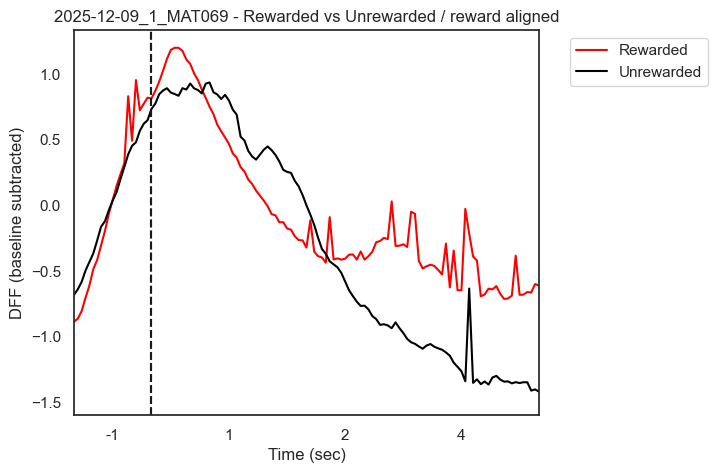

In [ ]:
########## LETS CREATE SOME HEATMAPS

colormap = ['red', 'black']
savefigname = 'LinePlot-mean-reward_' + str(duration[0]) + 'sec'
analysis_params = ['Rewarded', 'Unrewarded']
pfun.lineplot_sessions(pupilTrace_mean_reward, analysis_params, colormap,
                    duration, zscoreRun, savefigname, subfolder_path, baseline_subtract, 
                    title=f'{title_prefix} - Rewarded vs Unrewarded / reward aligned', visualParams = params) 


In [ ]:
#10> Save info into the analysis folder
filenameINFO = info.analysisPath + '\\infoForAnalysis.pkl'
with open(filenameINFO, 'wb') as f:
    pickle.dump(info, f)
print('All should be done!!')

# Save table as CSV
recordingList = info.recordingList
recordingList.to_csv( info.analysisPath +'\\recordingList.csv', index=False)